# Phase 2: Data Preprocessing 


In [8]:
# import libraries


import os
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.21.0


In [9]:
# Define Dataset path


DATASET_PATH = r"C:\Users\khage\Garbage-Classification\dataset"

assert os.path.exists(DATASET_PATH), "Dataset path not found."

print("Dataset Found Successfully!")

Dataset Found Successfully!


In [10]:
#  Define Parameters
IMAGE_SIZE = (160,160)

BATCH_SIZE = 8

SEED = 42

print("Image Size :", IMAGE_SIZE)
print("Batch Size :", BATCH_SIZE)


Image Size : (160, 160)
Batch Size : 8


In [11]:
# Data Augmentation


train_datagen = ImageDataGenerator(

    rescale=1./255,

    validation_split=0.20,

    rotation_range=20,

    width_shift_range=0.2,

    height_shift_range=0.2,

    zoom_range=0.2,

    horizontal_flip=True,

    fill_mode="nearest"
)

In [12]:
#  Validation Generator

validation_datagen = ImageDataGenerator(

    rescale=1./255,

    validation_split=0.20
)

In [13]:
# Create Training Dataset

train_generator = train_datagen.flow_from_directory(

    DATASET_PATH,

    target_size=IMAGE_SIZE,

    batch_size=BATCH_SIZE,

    class_mode="categorical",

    subset="training",

    shuffle=True,

    seed=SEED
)

Found 2024 images belonging to 6 classes.


In [14]:
#  Create Validation Dataset

validation_generator = validation_datagen.flow_from_directory(

    DATASET_PATH,

    target_size=IMAGE_SIZE,

    batch_size=BATCH_SIZE,

    class_mode="categorical",

    subset="validation",

    shuffle=False,

    seed=SEED
)

Found 503 images belonging to 6 classes.


In [16]:
# Display Class Indices


print("Class Indices")

print("="*50)

print(train_generator.class_indices)

Class Indices
{'cardboard': 0, 'glass': 1, 'metal': 2, 'paper': 3, 'plastic': 4, 'trash': 5}


In [17]:
#  Verify a Batch

images, labels = next(train_generator)

print("Image Batch Shape :", images.shape)

print("Label Batch Shape :", labels.shape)

Image Batch Shape : (8, 160, 160, 3)
Label Batch Shape : (8, 6)


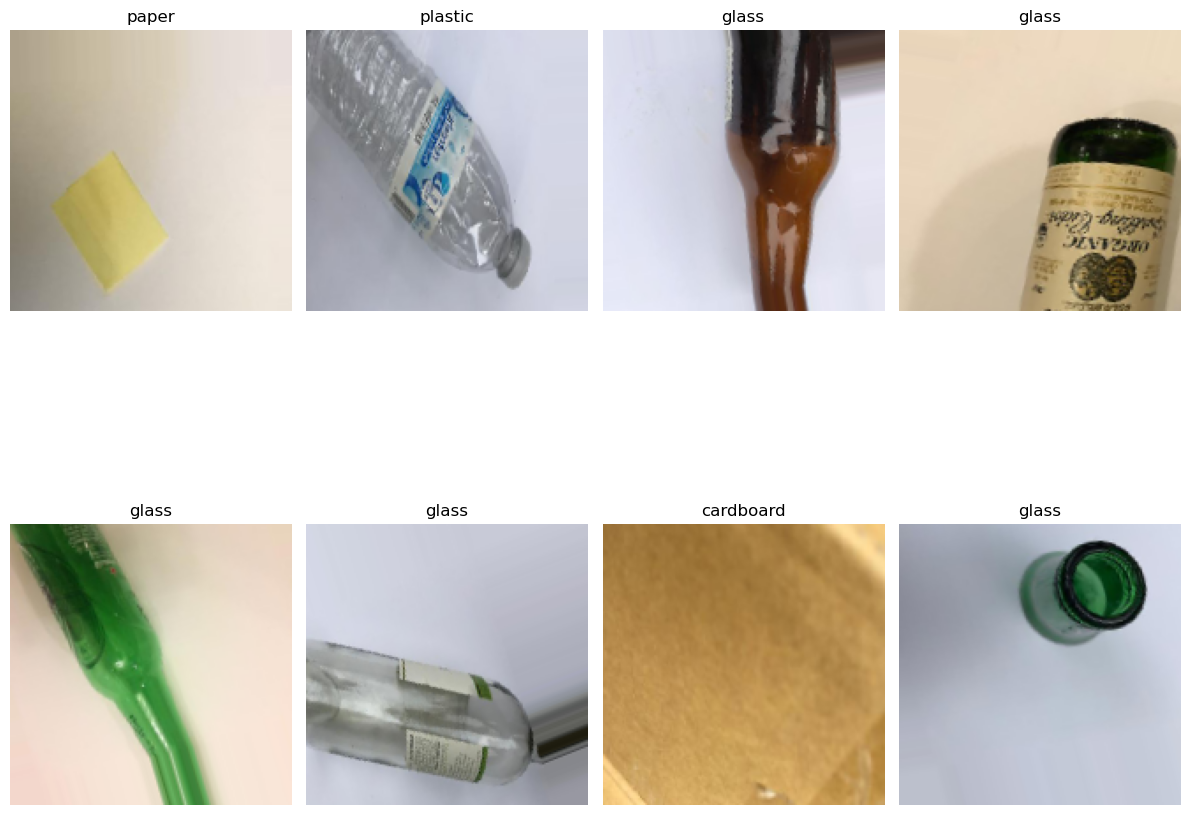

In [18]:
# Visualize Preprocessed Images

import matplotlib.pyplot as plt

class_names = list(train_generator.class_indices.keys())

plt.figure(figsize=(12,12))

for i in range(8):

    plt.subplot(2,4,i+1)

    plt.imshow(images[i])

    plt.title(class_names[labels[i].argmax()])

    plt.axis("off")

plt.tight_layout()

plt.show()